Notebook de exploracion. La logica final va en `src/`.

In [101]:
%reload_ext autoreload
%autoreload 2

spark.sparkContext.setLogLevel("ERROR")
import pyspark.sql.functions as F

# 1. Data Loading

**Objective:** Load the datasets into Spark and verify that the environment is correctly configured.

- Configure the Spark session.
- Define the project and dataset paths.
- Load all datasets into Spark DataFrames.

In [102]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[2]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from common.spark_session import create_spark_session

spark = create_spark_session(app_name="sales-etl")

print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)
print("Parallelism:", spark.sparkContext.defaultParallelism)
print("Java:", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

Spark: 4.2.0
Master: local[*]
Parallelism: 8
Java: 17.0.20


In [3]:
DATASETS_PATH = PROJECT_ROOT / "datasets" / "01-sales"

for file in DATASETS_PATH.iterdir():
    print(file.name)

olist_sellers_dataset.csv
.DS_Store
product_category_name_translation.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv


In [4]:
dfs = {}
for file in DATASETS_PATH.glob("olist_*_dataset.csv"):
    df_name = (
        file.name
        .removeprefix("olist_")
        .removesuffix("_dataset.csv")
    )

    df_path = (
        file
    )
    dfs[df_name] = df_path

dfs

{'sellers': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/01-sales/olist_sellers_dataset.csv'),
 'orders': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/01-sales/olist_orders_dataset.csv'),
 'order_items': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/01-sales/olist_order_items_dataset.csv'),
 'customers': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/01-sales/olist_customers_dataset.csv'),
 'geolocation': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/01-sales/olist_geolocation_dataset.csv'),
 'order_payments': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/01-sales/olist_order_payments_dataset.csv'),
 'order_reviews': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/01-sales/olist_order_reviews_dataset.csv'),
 'products': PosixPath('/Users/gloriadelriomarquez/Documents/Career/spark-lab/datasets/0

In [5]:
dataframes = {}

for name, path in dfs.items():
    dataframes[name] = (
        spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv(str(path))
    )


order_reviews_path = DATASETS_PATH / "olist_order_reviews_dataset.csv"

dataframes['order_reviews'] = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("multiLine", True) \
    .option("escape", '"') \
    .option("quote", '"') \
    .csv(str(order_reviews_path))

pcn_translation_path = DATASETS_PATH / "product_category_name_translation.csv"

dataframes['product_category_name_translation'] = spark.read\
                                        .option("header","true")\
                                        .option('InferSchema',"true")\
                                        .csv(str(pcn_translation_path))

# Cache: todas las tablas se recorren repetidamente en las secciones de
# inventario, esquema, estadisticas, cardinalidad y calidad (count, show,
# summary, groupBy...). Cachearlas evita releer y reprocesar el CSV en cada accion.
for name, df in dataframes.items():
    dataframes[name] = df.cache()

In [6]:
print(dataframes.keys())
print("Total dfs:",len(dataframes.keys()))

dict_keys(['sellers', 'orders', 'order_items', 'customers', 'geolocation', 'order_payments', 'order_reviews', 'products', 'product_category_name_translation'])
Total dfs: 9


In [50]:
for df_name, df in dataframes.items():
    globals()[df_name] = df

# 2. Data Inventory

**Objective:** Understand the available data at a high level.

- Number of tables.
- Number of rows.
- Number of columns.


In [8]:
for df_name, df in dataframes.items():
    print(f"{df_name}: {df.count()} filas, {len(df.columns)} columnas")

sellers: 3095 filas, 4 columnas


orders: 99441 filas, 8 columnas
order_items: 112650 filas, 7 columnas
customers: 99441 filas, 5 columnas
geolocation: 1000163 filas, 5 columnas
order_payments: 103886 filas, 5 columnas
order_reviews: 99224 filas, 7 columnas
products: 32951 filas, 9 columnas
product_category_name_translation: 71 filas, 2 columnas


# 3. Data Structure

**Objective:** Inspect the schema of each dataset.

- Data types.
- Column names.
- Schema.


In [7]:
for df_name, df in dataframes.items():
    print(f"\n===== {df_name.upper()} =====")
    df.printSchema()


===== SELLERS =====
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = true)
 |-- seller_city: string (nullable = true)
 |-- seller_state: string (nullable = true)


===== ORDERS =====
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


===== ORDER_ITEMS =====
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


# 4. Data understanding

- Sample (show())
- Basic statistics (stadistics of numeric cols)  
- Cardinality (distribution and unique values of categorical cols)
- Data distribution (if required)

### Sample

In [58]:
for df_name, df in dataframes.items():
    print(f"\n===== {df_name.upper()} =====")
    df.show(5)


===== SELLERS =====
+--------------------+----------------------+-----------------+------------+
|           seller_id|seller_zip_code_prefix|      seller_city|seller_state|
+--------------------+----------------------+-----------------+------------+
|3442f8959a84dea7e...|                 13023|         campinas|          SP|
|d1b65fc7debc3361e...|                 13844|       mogi guacu|          SP|
|ce3ad9de960102d06...|                 20031|   rio de janeiro|          RJ|
|c0f3eea2e14555b6f...|                  4195|        sao paulo|          SP|
|51a04a8a6bdcb23de...|                 12914|braganca paulista|          SP|
+--------------------+----------------------+-----------------+------------+
only showing top 5 rows

===== ORDERS =====
+--------------------+--------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|            order_id|         customer_id|order_st

### Stadistics of numeric cols

In [57]:
from common.profiling import numeric_summary

for df_name, df in dataframes.items():
    summary = numeric_summary(df)
    
    if not summary: 
        print(f"\n===== {df_name.upper()} =====:\n ✅ No numeric cols")
    else: 
        print(f"\n===== {df_name.upper()} =====")
        summary.show()


===== SELLERS =====
+-------+----------------------+
|summary|seller_zip_code_prefix|
+-------+----------------------+
|  count|                  3095|
|   mean|    32291.059450726978|
| stddev|     32713.45382950901|
|    min|                  1001|
|    25%|                  7093|
|    50%|                 14940|
|    75%|                 65072|
|    max|                 99730|
+-------+----------------------+


===== ORDERS =====:
 ✅ No numeric cols

===== ORDER_ITEMS =====
+-------+------------------+------------------+------------------+
|summary|     order_item_id|             price|     freight_value|
+-------+------------------+------------------+------------------+
|  count|            112650|            112650|            112650|
|   mean|1.1978339991122948|120.65373901464174|19.990319928982977|
| stddev|0.7051240313951721| 183.6339280502595|15.806405412297098|
|    min|                 1|              0.85|               0.0|
|    25%|                 1|              39.9| 

+-------+---------------------------+-------------------+-------------------+
|summary|geolocation_zip_code_prefix|    geolocation_lat|    geolocation_lng|
+-------+---------------------------+-------------------+-------------------+
|  count|                    1000163|            1000163|            1000163|
|   mean|          36574.16646586607|-21.176152910383912| -46.39054132093581|
| stddev|         30549.335710319807|  5.715866308822884|  4.269748306619736|
|    min|                       1001|  -36.6053744107061|-101.46676644931476|
|    25%|                      11075|-23.603588937272793| -48.57355623077272|
|    50%|                      26535|-22.919398071614008| -46.63789185345377|
|    75%|                      63502| -19.97962682041671| -43.76780702623862|
|    max|                      99990|  45.06593318269697| 121.10539381057764|
+-------+---------------------------+-------------------+-------------------+


===== ORDER_PAYMENTS =====
+-------+------------------+-------

[Stage 1181:>                                                       (0 + 1) / 1]

+-------+-------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+
|summary|product_name_lenght|product_description_lenght|product_photos_qty|  product_weight_g| product_length_cm| product_height_cm|  product_width_cm|
+-------+-------------------+--------------------------+------------------+------------------+------------------+------------------+------------------+
|  count|              32341|                     32341|             32341|             32949|             32949|             32949|             32949|
|   mean|  48.47694876472589|         771.4952846232337|2.1889861166939797|2276.4724877841513| 30.81507784758263|16.937661234028347|23.196728277034204|
| stddev| 10.245740725237287|         635.1152246349538|1.7367656379315435| 4282.038730977024|16.914458054065953|13.637554061749569|12.079047453227794|
|    min|                  5|                         4|                 1|             

### Cardinality  

In [45]:
from common.profiling import cardinality_profile

for df_name, df in dataframes.items():
    print(f"\n===== {df_name.upper()} =====")
    cardinality_profile(df).show()


===== SELLERS =====
+--------------------+---------------+---------------+
|         column_name|distinct_values|cardinality_pct|
+--------------------+---------------+---------------+
|           seller_id|           3095|          100.0|
|seller_zip_code_p...|           2246|          72.57|
|         seller_city|            611|          19.74|
|        seller_state|             23|           0.74|
+--------------------+---------------+---------------+


===== ORDERS =====
+--------------------+---------------+---------------+
|         column_name|distinct_values|cardinality_pct|
+--------------------+---------------+---------------+
|            order_id|          99441|          100.0|
|         customer_id|          99441|          100.0|
|order_purchase_ti...|          98875|          99.43|
|order_delivered_c...|          95664|           96.2|
|   order_approved_at|          90733|          91.24|
|order_delivered_c...|          81018|          81.47|
|order_estimated_d...| 

+--------------------+---------------+---------------+
|         column_name|distinct_values|cardinality_pct|
+--------------------+---------------+---------------+
|     geolocation_lng|         717615|          71.75|
|     geolocation_lat|         717372|          71.73|
|geolocation_zip_c...|          19015|            1.9|
|    geolocation_city|           8011|            0.8|
|   geolocation_state|             27|            0.0|
+--------------------+---------------+---------------+


===== ORDER_PAYMENTS =====


+--------------------+---------------+---------------+
|         column_name|distinct_values|cardinality_pct|
+--------------------+---------------+---------------+
|            order_id|          99440|          95.72|
|       payment_value|          29077|          27.99|
|  payment_sequential|             29|           0.03|
|payment_installments|             24|           0.02|
|        payment_type|              5|            0.0|
+--------------------+---------------+---------------+


===== ORDER_REVIEWS =====
+--------------------+---------------+---------------+
|         column_name|distinct_values|cardinality_pct|
+--------------------+---------------+---------------+
|            order_id|          98673|          99.44|
|           review_id|          98410|          99.18|
|review_answer_tim...|          98248|          99.02|
|review_comment_me...|          36159|          36.44|
|review_comment_title|           4527|           4.56|
|review_creation_date|            636

# 5. Data Quality Assessment

**Objective:** Evaluate the quality of the data before building transformations.

- Duplicate records.
- Missing values.
- Outliers or anomalous values.

### Duplicates

In [29]:

from common.profiling import duplicate_count, show_result

for df_name, df in dataframes.items():
    result = duplicate_count(df)
    duplicate_rows = result.first()["duplicate_rows"] or 0
    
    if duplicate_rows == 0:
        print(f"{df_name}: ✅ No duplicate rows")
    else:
        print(f"{df_name:}")
        result.show(truncate = False)

sellers: ✅ No duplicate rows
orders: ✅ No duplicate rows
order_items: ✅ No duplicate rows
customers: ✅ No duplicate rows


[Stage 662:=======>                                                 (1 + 7) / 8]

geolocation


+----------------+--------------+
|duplicate_groups|duplicate_rows|
+----------------+--------------+
|128174          |261831        |
+----------------+--------------+

order_payments: ✅ No duplicate rows
order_reviews: ✅ No duplicate rows
products: ✅ No duplicate rows
product_category_name_translation: ✅ No duplicate rows


In [9]:
geolocation = dataframes['geolocation']

duplicate_rows = (
    geolocation
    .groupBy(geolocation.columns)
    .count()
    .filter(F.col("count") > 1)
)

duplicate_rows.show(5, truncate=False)

[Stage 47:==============>                                           (2 + 6) / 8]

+---------------------------+-------------------+------------------+----------------+-----------------+-----+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|count|
+---------------------------+-------------------+------------------+----------------+-----------------+-----+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |2    |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |6    |
|1013                       |-23.546923208436723|-46.6342636964915 |sao paulo       |SP               |3    |
|1013                       |-23.547325128224376|-46.63418378613892|sao paulo       |SP               |3    |
|1009                       |-23.54693540437998 |-46.63658792659698|sao paulo       |SP               |12   |
+---------------------------+-------------------+------------------+----------------+-----------------+-----+
only showi

### Missings

#### Absolute

In [30]:
from common.profiling import missing_values_profile

missing_markers = {
    "na_count": "NA",
    "unknown_count": "Unknown",
    "empty_count": "",
}

for df_name, df in dataframes.items():
    print(f"\n===== {df_name.upper()} =====")
    
    result = missing_values_profile(df, string_markers = missing_markers )
    
    if result.isEmpty():
        print("✅ No missing values found.")
    else:
        result.show(truncate=False)



===== SELLERS =====
✅ No missing values found.

===== ORDERS =====
+-----------------------------+----------+---------+--------+-------------+-----------+-------------+
|column_name                  |null_count|nan_count|na_count|unknown_count|empty_count|missing_total|
+-----------------------------+----------+---------+--------+-------------+-----------+-------------+
|order_delivered_customer_date|2965      |0        |0       |0            |0          |2965         |
|order_delivered_carrier_date |1783      |0        |0       |0            |0          |1783         |
|order_approved_at            |160       |0        |0       |0            |0          |160          |
+-----------------------------+----------+---------+--------+-------------+-----------+-------------+


===== ORDER_ITEMS =====
✅ No missing values found.

===== CUSTOMERS =====
✅ No missing values found.

===== GEOLOCATION =====
✅ No missing values found.

===== ORDER_PAYMENTS =====
✅ No missing values found.

===== O

#### Percentage

In [36]:
from common.profiling import missing_values_profile

for df_name, df in dataframes.items():
    print(f"\n===== {df_name.upper()} =====")
    
    result = missing_values_profile(df, string_markers = missing_markers, output ='percentage')
    
    if result.isEmpty():
        print("✅ No missing values found.")
    else:
        result.show(truncate=False)


===== SELLERS =====
✅ No missing values found.

===== ORDERS =====
+-----------------------------+----------+---------+--------+-------------+-----------+-------------+
|column_name                  |null_count|nan_count|na_count|unknown_count|empty_count|missing_total|
+-----------------------------+----------+---------+--------+-------------+-----------+-------------+
|order_delivered_customer_date|2.98      |0.0      |0.0     |0.0          |0.0        |2.98         |
|order_delivered_carrier_date |1.79      |0.0      |0.0     |0.0          |0.0        |1.79         |
|order_approved_at            |0.16      |0.0      |0.0     |0.0          |0.0        |0.16         |
+-----------------------------+----------+---------+--------+-------------+-----------+-------------+


===== ORDER_ITEMS =====
✅ No missing values found.

===== CUSTOMERS =====
✅ No missing values found.

===== GEOLOCATION =====
✅ No missing values found.

===== ORDER_PAYMENTS =====
✅ No missing values found.

===== O

### Inconsistencies

- fechas futuras
- precio <= 0 
- cantidad = 0
- estado inexistente
- order_date <= delivery_date
- payment >= 0
- score entre 1 y 5
- payment_value = price + freight_value 

# Conclusiones

#### Registros duplicados

- La tabla `geolocation` contiene filas completamente duplicadas. Estos registros no aportan información adicional y podrían eliminarse durante el proceso de limpieza de datos sin pérdida de información.
- 
#### Valores ausentes

- **orders**: las ausencias están asociadas al ciclo de vida de los pedidos. Es normal que los pedidos no aprobados, no enviados o no entregados aún no dispongan de determinadas fechas.
- **products**: existen productos sin categoría, descripción o dimensiones. Estos registros deberán evaluarse antes de utilizarlos en análisis posteriores.
- **order_reviews**: las ausencias se concentran en el título y el comentario de la reseña. Es un comportamiento habitual en plataformas de comercio electrónico que los clientes valoren un pedido mediante una puntuación sin añadir un comentario textual.
- **Resto de tablas**: no se han detectado representaciones de valores ausentes.

#### Preguntas abiertas

Las siguientes cuestiones deberán resolverse antes de diseñar el modelo analítico y el proceso ETL:

- ¿Cómo tratar los productos que no disponen de `product_category_name`?
- ¿Qué estrategia seguir con los productos que carecen de descripción o dimensiones? ¿Eliminar, imputar o mantener estos registros?
- ¿Es necesario eliminar o consolidar las filas duplicadas de `geolocation`, o forman parte del diseño esperado del conjunto de datos?
- ¿Qué criterio se seguirá para analizar los tiempos de entrega en pedidos que todavía no han sido entregados?


# 6. Relational Model

**Objective:** Understand how the datasets are related.

- Primary keys.
- Foreign keys.
- Referential integrity
- Relationships.
- Relational diagram.

### Primary keys

In [7]:
import importlib
import common.relational as relational

importlib.reload(relational)

from common.relational import primary_key_check

primary_keys = {
    "customers": "customer_id",
    "orders": "order_id",
    "products": "product_id",
    "sellers": "seller_id",
    "order_reviews": "review_id",
    "order_payments": ["order_id", "payment_sequential"],
    "order_items": ["order_id", "order_item_id"],
    "product_category_name_translation": "product_category_name",
}


for table_name, pk in primary_keys.items():
    print(f"\n=== {table_name} ===")
    primary_key_check(dataframes[table_name], pk).show(truncate=False)


=== customers ===
+----------+------------------+-------------+--------------+--------------------+
|total_rows|rows_with_null_key|distinct_keys|duplicate_keys|is_valid_primary_key|
+----------+------------------+-------------+--------------+--------------------+
|99441     |0                 |99441        |0             |true                |
+----------+------------------+-------------+--------------+--------------------+


=== orders ===
+----------+------------------+-------------+--------------+--------------------+
|total_rows|rows_with_null_key|distinct_keys|duplicate_keys|is_valid_primary_key|
+----------+------------------+-------------+--------------+--------------------+
|99441     |0                 |99441        |0             |true                |
+----------+------------------+-------------+--------------+--------------------+


=== products ===
+----------+------------------+-------------+--------------+--------------------+
|total_rows|rows_with_null_key|distinct_key

### Foreing keys

- `orders.customer_id` → `customers.customer_id`
- `order_items.order_id` → `orders.order_id`
- `order_items.product_id` → `products.product_id`
- `order_items.seller_id` → `sellers.seller_id`
- `order_payments.order_id` → `orders.order_id`
- `order_reviews.order_id` → `orders.order_id`
- `products.product_category_name` → `product_category_name_translation.product_category_name`

In [9]:
foreign_keys = [
    ("orders", "customer_id", "customers", "customer_id"), # ¿Todos los customer_id que aparecen en orders existen en customers?
    ("order_items", "order_id", "orders", "order_id"),
    ("order_items", "product_id", "products", "product_id"),
    ("order_items", "seller_id", "sellers", "seller_id"),
    ("order_payments", "order_id", "orders", "order_id"),
    ("order_reviews", "order_id", "orders", "order_id"),
    ("products", "product_category_name", "product_category_name_translation", "product_category_name")
]

In [11]:
from common.relational import foreign_key_check

for child_table, child_column, parent_table, parent_column in foreign_keys:
    print(f"\n=== {child_table}.{child_column} → {parent_table}.{parent_column} ===")

    foreign_key_check(
        dataframes[child_table],
        child_column,
        dataframes[parent_table],
        parent_column,
    ).show(truncate=False)


=== orders.customer_id → customers.customer_id ===
+-----------+-----------+
|orphan_rows|orphan_keys|
+-----------+-----------+
|0          |0          |
+-----------+-----------+


=== order_items.order_id → orders.order_id ===
+-----------+-----------+
|orphan_rows|orphan_keys|
+-----------+-----------+
|0          |0          |
+-----------+-----------+


=== order_items.product_id → products.product_id ===
+-----------+-----------+
|orphan_rows|orphan_keys|
+-----------+-----------+
|0          |0          |
+-----------+-----------+


=== order_items.seller_id → sellers.seller_id ===
+-----------+-----------+
|orphan_rows|orphan_keys|
+-----------+-----------+
|0          |0          |
+-----------+-----------+


=== order_payments.order_id → orders.order_id ===
+-----------+-----------+
|orphan_rows|orphan_keys|
+-----------+-----------+
|0          |0          |
+-----------+-----------+


=== order_reviews.order_id → orders.order_id ===
+-----------+-----------+
|orphan_rows|

13 filas de la tabla products tienen un valor de product_category_name que no existe en la tabla de traducción.  
Esas 13 filas corresponden únicamente a 2 categorías distintas (orphan_keys = 2).  

### Relaciones y cardinalidad

Las relaciones esperadas serían:

Relación	Cardinalidad esperada
customers → orders	1:1 mediante customer_id
Persona real → orders	1:N mediante customer_unique_id
orders → order_items	1:N
orders → order_payments	1:N
orders → order_reviews	Generalmente 1:1
products → order_items	1:N
sellers → order_items	1:N
product_category_translation → products	1:N

In [24]:
# customer_unique_id → orders (1:N)

(
    dataframes["customers"]
    .join(
        dataframes["orders"],
        on="customer_id"
    )
    .groupBy("customer_unique_id")
    .count()
    .orderBy(F.desc("count"))
    .show(5)
)

# Nº de pedidos por cliente

+--------------------+-----+
|  customer_unique_id|count|
+--------------------+-----+
|8d50f5eadf50201cc...|   17|
|3e43e6105506432c9...|    9|
|ca77025e7201e3b30...|    7|
|1b6c7548a2a1f9037...|    7|
|6469f99c1f9dfae77...|    7|
+--------------------+-----+
only showing top 5 rows


In [23]:
# products → order_items (1:N)
(
    dataframes['order_items']
        .groupBy('product_id')
        .count()
        .summary()
        .show()
)

# Hay un producto que se ha vendido como máx 527 veces
# De media se venden 3 productos por pedido

+-------+--------------------+------------------+
|summary|          product_id|             count|
+-------+--------------------+------------------+
|  count|               32951|             32951|
|   mean|                NULL|3.4187126339109586|
| stddev|                NULL|10.619708568011463|
|    min|00066f42aeeb9f300...|                 1|
|    25%|                NULL|                 1|
|    50%|                NULL|                 1|
|    75%|                NULL|                 3|
|    max|fffe9eeff12fcbd74...|               527|
+-------+--------------------+------------------+



In [21]:
# order_id

(
    dataframes["order_items"]
    .groupBy("order_id")
    .count()
    .summary()
    .show()
)

# Pedidos totales: 98666
# Máximo 21 artículos por pedido

+-------+--------------------+------------------+
|summary|            order_id|             count|
+-------+--------------------+------------------+
|  count|               98666|             98666|
|   mean|                NULL|1.1417306873695092|
| stddev|                NULL|0.5384523739205166|
|    min|00010242fe8c5a6d1...|                 1|
|    25%|                NULL|                 1|
|    50%|                NULL|                 1|
|    75%|                NULL|                 1|
|    max|fffe41c64501cc87c...|                21|
+-------+--------------------+------------------+



In [20]:
(dataframes["order_reviews"]
    .groupBy("order_id")
    .count()
    .filter(F.col("count") > 1)
    .count()
)

# Un mismo pedido (order_id) puede tener varias reseñas

547

## Conclusiones

- Todas las claves primarias candidatas son válidas.
- Todas las relaciones mantienen la integridad referencial salvo products.product_category_name, donde existen 13 productos pertenecientes a 2 categorías sin traducción.
- La relación orders → order_reviews no es estrictamente 1:1; se observan 547 pedidos con múltiples reseñas.

# 7. Business Rules

**Objective:** Identify the business logic represented by the data.

- Implicit business rules.
- Constraints and assumptions.
- Data limitations.

##  Conclusiones

- `customer_id` identifica un cliente dentro de un pedido y actúa como clave primaria de la tabla `customers`.
- `customer_unique_id` identifica a la persona real. Un mismo cliente puede realizar varios pedidos y disponer de distintos `customer_id`, pero siempre conservará el mismo `customer_unique_id`.
- La puntuación de las reseñas (`review_score`) está comprendida entre **1 y 5**.
- Un mismo pedido puede contener productos vendidos por distintos vendedores. Por tanto, la relación entre `orders` y `sellers` se realiza a través de la tabla `order_items`.
- La fecha `shipping_limit_date` pertenece a cada artículo del pedido (`order_items`), no al pedido completo. Un mismo pedido puede tener varias fechas límite de envío.

### Restricciones y consideraciones

- Las fechas del ciclo de vida de un pedido (`order_approved_at`, `order_delivered_carrier_date` y `order_delivered_customer_date`) pueden ser nulas cuando el pedido todavía no ha alcanzado esa fase del proceso.
- La ausencia de título o comentario en una reseña no implica la ausencia de valoración, ya que un cliente puede puntuar un pedido sin añadir un comentario textual.

### Limitaciones del conjunto de datos

- La tabla `geolocation` contiene filas duplicadas, por lo que no debe asumirse que cada registro representa una ubicación única.
- Existen productos sin categoría, descripción o dimensiones, lo que puede afectar a determinados análisis y requerirá definir una estrategia de tratamiento durante el proceso ETL. 

In [10]:
customer_records = customers.select("customer_id").distinct().count()
unique_customers = customers.select("customer_unique_id").distinct().count()

print("Customer records:", customer_records)
print("Unique customers:", unique_customers)
print("Repeated purchases:", customer_records - unique_customers)

Customer records: 99441
Unique customers: 96096
Repeated purchases: 3345


# 8. Business Questions

**Objective:** Define the analytical goals that will guide the ETL process.

- Business questions to answer.
- Expected analyses.
- Transformations required to support those analyses.

**Estado de los apartados:**
- Clientes ✅ completado
- Pedidos ✅ completado (incluye estados con más retrasos)
- Productos 🔧 pendiente (sección nueva, añadida más abajo)
- Proveedores 🔧 parcialmente pendiente
- Ventas / KPIs generales 🔧 pendiente


#### Clientes 
- ¿Cuántos clientes únicos compraron?
- ¿Cuántos pedidos hace cada cliente de media?
- ¿Cuál es el ticket medio por cliente? 
- ¿Cuál es la tasa de repetición de compra?
- ¿Cómo se distribuyen los clientes por estado o ciudad?

In [51]:
# ¿Cuántos clientes únicos compraron?
unique_clients_with_purchases= orders.join(customers, on='customer_id')\
                                      .agg(F.countDistinct(F.col('customer_unique_id')).alias('unique_clients'))
                                      
unique_clients_with_purchases.show()

+--------------+
|unique_clients|
+--------------+
|         96096|
+--------------+



In [52]:
# ¿Cuántos pedidos hace cada cliente de media?

orders_clients= orders.join(customers, on='customer_id')\
                                      .groupBy('customer_unique_id')\
                                      .agg ( F.count(F.col('order_id')).alias('n_orders') )
                                        
orders_clients.show(5)

+--------------------+--------+
|  customer_unique_id|n_orders|
+--------------------+--------+
|af07308b275d755c9...|       1|
|80bb27c7c16e8f973...|       1|
|e2dfa3127fedbbca9...|       1|
|ccafc1c3f27041052...|       2|
|d0ff1a7468fcc46b8...|       1|
+--------------------+--------+
only showing top 5 rows


In [53]:
# Nº de pedidos medio por cliente

orders_clients_total= orders.join(customers, on='customer_id')\
                                      .groupBy('customer_unique_id')\
                                      .agg ( F.count(F.col('order_id')).alias('n_orders') )\
                                      .agg ( F.mean(F.col('n_orders')).alias('total_mean_orders') )

orders_clients_total.show()

+------------------+
| total_mean_orders|
+------------------+
|1.0348089410589412|
+------------------+



In [54]:
# ¿Cuál es el gasto medio por cliente? 
# Ticket medio por pedido → usar order_id.

order_total = order_payments.groupBy('order_id')\
                            .agg(F.sum('payment_value').alias('order_total'))

mean_ticket = orders.join(customers, on ='customer_id')\
                    .join(order_total, on = 'order_id')\
                    .groupBy('customer_unique_id')\
                    .agg(F.mean('order_total').alias('mean_ticket'))

mean_ticket.orderBy('mean_ticket', ascending=False).show(5)

+--------------------+-----------+
|  customer_unique_id|mean_ticket|
+--------------------+-----------+
|0a0a92112bd4c708c...|   13664.08|
|763c8b1c9c68a0229...|    7274.88|
|dc4802a71eae9be1d...|    6929.31|
|459bef486812aa252...|    6922.21|
|ff4159b92c40ebe40...|    6726.66|
+--------------------+-----------+
only showing top 5 rows


In [55]:
mean_ticket.agg(
    F.round(F.mean('mean_ticket'),2).alias('overall_mean_ticket')
).show()

+-------------------+
|overall_mean_ticket|
+-------------------+
|              161.4|
+-------------------+



In [56]:
# ¿Cuál es la tasa de repetición de compra?
# Clientes con más de 1 pediddo / clientes totales

customer_orders = orders.join(customers,on = 'customer_id')\
      .groupBy('customer_unique_id')\
      .agg(F.countDistinct(F.col('order_id')).alias('num_orders'))

repeat_rate =  customer_orders\
    .agg(
          (100 * F.mean(
                 F.when(F.col('num_orders')>1,1).otherwise(0)
                 )
          ).alias('repeat_purchase')
    )

repeat_rate.show()
      

+------------------+
|   repeat_purchase|
+------------------+
|3.1187562437562435|
+------------------+



In [57]:
customer_orders.groupBy("num_orders").count().orderBy("num_orders", ascending=False).show(5)

+----------+-----+
|num_orders|count|
+----------+-----+
|        17|    1|
|         9|    1|
|         7|    3|
|         6|    6|
|         5|    8|
+----------+-----+
only showing top 5 rows


In [58]:
# ¿Procedencia de los clientes por estado o ciudad?
customers.groupBy('customer_state').agg(F.countDistinct('customer_unique_id').alias('num_clients')).show(5)

+--------------+-----------+
|customer_state|num_clients|
+--------------+-----------+
|            SP|      40302|
|            SC|       3534|
|            RS|       5277|
|            BA|       3277|
|            PI|        482|
+--------------+-----------+
only showing top 5 rows


#### Pedidos 
- ¿Cuál es el ticket medio por pedido?
- ¿Cuántos pedidos se entregaron tarde?
- ¿Cuántos días de retraso tuvieron?
- ¿Qué porcentaje se entregó antes, en fecha o después de la fecha estimada?
- ¿Qué estados presentan más retrasos?

In [198]:
# ¿Cuál es el ticket medio por pedido?

mean_order_income = order_items\
    .groupBy('order_id')\
    .agg(
        F.round(F.sum('price'),2).alias('mean_income') # importe de cada pedido
    )\
    .agg(
        F.round(F.mean('mean_income'),2).alias('mean_order_income') # media de todos los importes (ticket medio)
    )
    
mean_order_income.show()

+-----------------+
|mean_order_income|
+-----------------+
|           125.92|
+-----------------+



In [59]:
# ¿Cuántos pedidos se entregaron tarde?
orders.filter( F.col('order_delivered_customer_date') > F.col('order_estimated_delivery_date')).count()

7827

In [60]:
# Categorización de pedidos

orders = orders.withColumn(
    "delivery_state",
        F.when(
            F.col("order_delivered_customer_date").isNull(), "not delivered")
        .when(
            F.col("order_delivered_customer_date") > F.col("order_estimated_delivery_date"), "delayed")
        .when(
            F.col("order_delivered_customer_date") == F.col("order_estimated_delivery_date"), "on date")
        .otherwise("before time")
)

In [104]:
# Para los pedidos atrasados ¿Cuántos días de retraso tuvieron?

orders = orders.withColumn('delay_days',
                  F.when( F.col("delivery_state")=='delayed', 
                  F.date_diff( 
                      F.col("order_delivered_customer_date"), 
                      F.col("order_estimated_delivery_date") 
                             ) 
                        )
                 )


# orders ahora incluye delivery_state y delay_days, y se reutiliza en el
# calculo de porcentajes (mas abajo) y en el analisis de vendedores.
orders = orders.cache()

orders.filter(F.col('delivery_state')=='delayed').select('order_id','delivery_state','delay_days').show(5)


+--------------------+--------------+----------+
|            order_id|delivery_state|delay_days|
+--------------------+--------------+----------+
|203096f03d82e0dff...|       delayed|        11|
|fbf9ac61453ac646c...|       delayed|         9|
|8563039e855156e48...|       delayed|         0|
|6ea2f835b4556291f...|       delayed|         7|
|66e4624ae69e7dc89...|       delayed|         1|
+--------------------+--------------+----------+
only showing top 5 rows


In [62]:
# ¿Qué porcentaje se entregó antes, en fecha o después de la fecha estimada?

In [63]:
total_orders = orders.count() 

# exlcuimos not delivered porque esos pedidos todavía no tienen un resultado final de entrega
delivery_stats = orders.filter(F.col('delivery_state') != 'not delivered' )\
                       .groupBy('delivery_state')\
                       .count()\
                       .withColumn(
                           "percentage", 
                           F.round( F.col('count')*100  / total_orders , 2)
                       )

delivery_stats.show()

+--------------+-----+----------+
|delivery_state|count|percentage|
+--------------+-----+----------+
|   before time|88649|     89.15|
|       delayed| 7827|      7.87|
+--------------+-----+----------+



In [64]:
orders.join(customers, on='customer_id').columns

['customer_id',
 'order_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_state',
 'delay_days',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [65]:
# ¿Qué estados presentan más retrasos?

delay_states = orders.join(customers, on='customer_id')\
                     .filter(F.col('delivery_state')=='delayed')\
                     .groupBy('customer_state')\
                     .agg(
                         F.count("*").alias('delays'),
                         F.round(F.mean(F.col('delay_days')), 2).alias('avg_delay_days')
                     )

delay_states.orderBy('delays',ascending=False).show(5)


+--------------+------+--------------+
|customer_state|delays|avg_delay_days|
+--------------+------+--------------+
|            SP|  2387|          6.35|
|            RJ|  1664|         12.15|
|            MG|   638|          6.85|
|            BA|   457|         10.42|
|            RS|   382|          8.71|
+--------------+------+--------------+
only showing top 5 rows


#### Productos
- ¿Qué productos se venden más (por unidades)?
- ¿Qué categorías venden más unidades?
- ¿Qué categorías generan más ingresos?
- ¿Cuál es el precio medio por categoría?
- ¿Qué categorías concentran la mayor parte de los ingresos (Pareto 80/20)?


In [68]:
# Recordemos que tenemos nulos en algunas categorías de productos
products.filter(
    F.col('product_category_name').isNull()
).count()

610

In [74]:
# ¿Qué productos se venden más ?
product_sells= order_items.groupBy("product_id")\
                           .agg(
                               F.count("*").alias("num_sells")
                           )\
                           .join(products_en.select("product_id", "product_category_name_english"),
                                on= 'product_id')\

product_sells.orderBy('num_sells',ascending=False).show(5)

+--------------------+---------+-----------------------------+
|          product_id|num_sells|product_category_name_english|
+--------------------+---------+-----------------------------+
|aca2eb7d00ea1a7b8...|      527|              furniture_decor|
|99a4788cb24856965...|      488|               bed_bath_table|
|422879e10f4668299...|      484|                 garden_tools|
|389d119b48cf3043d...|      392|                 garden_tools|
|368c6c730842d7801...|      388|                 garden_tools|
+--------------------+---------+-----------------------------+
only showing top 5 rows


In [73]:
# ¿Qué categorías venden más unidades?
products_en = (products.join(
        product_category_name_translation,
        on="product_category_name",
        how="left"
            )
        )

product_category_sells= order_items.join(products_en.select("product_id", "product_category_name_english"),
                                on= 'product_id')\
                           .groupBy("product_category_name_english")\
                           .agg(
                               F.count("*").alias("num_sells")
                           )

product_category_sells.orderBy('num_sells',ascending=False).show(5)

+-----------------------------+---------+
|product_category_name_english|num_sells|
+-----------------------------+---------+
|               bed_bath_table|    11115|
|                health_beauty|     9670|
|               sports_leisure|     8641|
|              furniture_decor|     8334|
|         computers_accesso...|     7827|
+-----------------------------+---------+
only showing top 5 rows


In [83]:
# ¿Qué categorías generan más ingresos?
category_income= order_items.join(products_en.select("product_id", "product_category_name_english"),
                 on="product_id")\
                 .groupBy('product_category_name_english')\
                 .agg(
                     F.round(F.sum('price'),2).alias('income')
                 )

category_income.orderBy(F.desc("income")).show(5)

+-----------------------------+----------+
|product_category_name_english|    income|
+-----------------------------+----------+
|                health_beauty|1258681.34|
|                watches_gifts|1205005.68|
|               bed_bath_table|1036988.68|
|               sports_leisure| 988048.97|
|         computers_accesso...| 911954.32|
+-----------------------------+----------+
only showing top 5 rows


In [84]:
# ¿Cuál es el precio medio por categoría?

# Sumamos el importe de los productos vendidos sin incluir el coste del envío (freight_value)

Según la pregunta, eso suele ser correcto porque "ingresos por categoría" normalmente se refiere al valor de los productos.

category_income= order_items.join(products_en.select("product_id", "product_category_name_english"),
                 on="product_id")\
                 .groupBy('product_category_name_english')\
                 .agg(
                     F.round(F.mean('price'),2).alias('mean_price')
                 )

category_income.orderBy(F.desc("mean_price")).show(5)

+-----------------------------+----------+
|product_category_name_english|mean_price|
+-----------------------------+----------+
|                    computers|   1098.34|
|         small_appliances_...|    624.29|
|            home_appliances_2|    476.12|
|         agro_industry_and...|    342.12|
|          musical_instruments|    281.62|
+-----------------------------+----------+
only showing top 5 rows


In [103]:
# ¿Qué categorías concentran la mayor parte de los ingresos (Pareto 80/20)?
# Pista: ordena categorías por ingresos desc y calcula el % acumulado.
from pyspark.sql.window import Window

# Ventana global necesaria para el cálculo del Pareto (80/20).
# Aunque Spark advierte que mueve los datos a una única partición, el impacto
# es despreciable porque la operación se realiza sobre un DataFrame ya agregado.

window = (
    Window
    .orderBy(F.desc("income"))
    .rowsBetween(
        Window.unboundedPreceding,
        Window.currentRow
    )
)

total_window = (
    Window
    .rowsBetween(
        Window.unboundedPreceding,
        Window.unboundedFollowing
    )
)


category_pareto= order_items.join(products_en.select("product_id", "product_category_name_english"),
                 on="product_id")\
                 .groupBy('product_category_name_english')\
                 .agg( F.sum('price') .alias('income') )\
                 .withColumn('cum_income', F.sum("income").over(window) )\
                 .withColumn('total_income', F.sum("income").over(total_window) )\
                 .withColumn('category_perc_income', F.col('income')*100 / F.col('total_income') )\
                 .withColumn('cum_perc_income', F.col('cum_income')*100 / F.col('total_income') )\
                 .drop("total_income")

# Redondeamos a 2 decimales
cols_to_round = [ "income","category_perc_income", "cum_perc_income"]
for col in cols_to_round:
    category_pareto = category_pareto.withColumn(
        col,
        F.round(col, 2)
    )

    
category_pareto.select('product_category_name_english','income', 'category_perc_income', 'cum_perc_income')\
    .orderBy(F.desc('category_perc_income')).show(5)

+-----------------------------+----------+--------------------+---------------+
|product_category_name_english|    income|category_perc_income|cum_perc_income|
+-----------------------------+----------+--------------------+---------------+
|                health_beauty|1258681.34|                9.26|           9.26|
|                watches_gifts|1205005.68|                8.87|          18.13|
|               bed_bath_table|1036988.68|                7.63|          25.76|
|               sports_leisure| 988048.97|                7.27|          33.03|
|         computers_accesso...| 911954.32|                6.71|          39.74|
+-----------------------------+----------+--------------------+---------------+
only showing top 5 rows


#### Proveedores 
- ¿Qué vendedores venden más unidades?
- ¿Qué vendedores generan más ingresos?
- ¿Cuántos pedidos gestiona cada vendedor?
- ¿Qué vendedores incumplen más el shipping_limit_date?
- ¿Existe relación entre el volumen de ventas y los retrasos?
- ¿Qué estados o ciudades concentran más vendedores?
- ¿Influye el peso del producto en el tiempo de entrega?

In [116]:
# ¿Qué vendedores venden más unidades?

top_sellers_by_products = order_items.groupBy('seller_id')\
                         .agg(
                             F.count("*").alias('num_products'),
                             F.round(F.sum('price'),2).alias("product_income")  
                         )\
                         .orderBy(F.desc('num_products'))
top_sellers_by_products.show(5)

+--------------------+------------+--------------+
|           seller_id|num_products|product_income|
+--------------------+------------+--------------+
|6560211a19b47992c...|        2033|     123304.83|
|4a3ca9315b744ce9f...|        1987|     200472.92|
|1f50f920176fa81da...|        1931|     106939.21|
|cc419e0650a3c5ba7...|        1775|     104288.42|
|da8622b14eb17ae28...|        1551|     160236.57|
+--------------------+------------+--------------+
only showing top 5 rows


In [117]:
# ¿Qué vendedores generan más ingresos?
top_sellers_by_income = order_items.groupBy('seller_id')\
                         .agg(
                             F.count("*").alias('num_products'),
                             F.round(F.sum('price'),2).alias("product_income")  
                         )\
                         .orderBy(F.desc('product_income'))
top_sellers_by_income.show(5)

+--------------------+------------+--------------+
|           seller_id|num_products|product_income|
+--------------------+------------+--------------+
|4869f7a5dfa277a7d...|        1156|     229472.63|
|53243585a1d6dc264...|         410|     222776.05|
|4a3ca9315b744ce9f...|        1987|     200472.92|
|fa1c13f2614d7b5c4...|         586|     194042.03|
|7c67e1448b00f6e96...|        1364|     187923.89|
+--------------------+------------+--------------+
only showing top 5 rows


In [122]:
# ¿Cuántos pedidos gestiona cada vendedor?
top_sellers_by_orders = order_items.groupBy('seller_id')\
                         .agg(
                             F.countDistinct(F.col('order_id')).alias('num_orders'),                             
                             F.count("*").alias('num_products'),
                             F.round(F.sum('price'),2).alias("product_income")  
                         )\
                         .orderBy(F.desc('num_orders'))
top_sellers_by_orders.show(5)

+--------------------+----------+------------+--------------+
|           seller_id|num_orders|num_products|product_income|
+--------------------+----------+------------+--------------+
|6560211a19b47992c...|      1854|        2033|     123304.83|
|4a3ca9315b744ce9f...|      1806|        1987|     200472.92|
|cc419e0650a3c5ba7...|      1706|        1775|     104288.42|
|1f50f920176fa81da...|      1404|        1931|     106939.21|
|da8622b14eb17ae28...|      1314|        1551|     160236.57|
+--------------------+----------+------------+--------------+
only showing top 5 rows


In [84]:
# ¿Qué vendedores incumplen más el shipping_limit_date?

# shipping_limit_date = fecha límite en la que el vendedor debe entregar el paquete al transportista
# order_delivered_carrier_date = fecha en la que el parquete fue entregado al transportista

shipping_compliance = order_items.join(orders.select("order_id", "order_delivered_carrier_date"), on='order_id')\
                                   .withColumn('late_shipping', 
                                               F.when(F.col('order_delivered_carrier_date') > F.col('shipping_limit_date') , 1) \
                                               .otherwise(0)
                                               )

seller_shipping = shipping_compliance.groupBy('seller_id')\
                                     .agg (
                                         F.count("*").alias("items"),
                                         F.sum('late_shipping').alias('late_items')
                                     )\
                                     .withColumn( 'late_rate', 
                                                  F.round( 
                                                      F.col('late_items')*100 / F.col("items"), 
                                                      2 )
                                                )\
                                     .orderBy('late_rate',ascending=False)

# Filtramos vendedores con un volumen mínimo - Top 10 vendedores con al menos 30 pedidos
seller_shipping.filter(F.col("items") >= 30).show(10)

+--------------------+-----+----------+---------+
|           seller_id|items|late_items|late_rate|
+--------------------+-----+----------+---------+
|48efc9d94a9834137...|   34|        28|    82.35|
|835f0f7810c76831d...|   50|        35|     70.0|
|a7f13822ceb966b07...|   86|        51|     59.3|
|a49928bcdf77c55c6...|  106|        59|    55.66|
|1da366cade6d8276e...|   49|        27|     55.1|
|54965bbe3e4f07ae0...|   86|        46|    53.49|
|1ca7077d890b907f8...|  137|        70|    51.09|
|88460e8ebdecbfecb...|  302|       151|     50.0|
|834f8533b2ecb6598...|   47|        23|    48.94|
|db2956745b3a8e9f3...|   48|        23|    47.92|
+--------------------+-----+----------+---------+
only showing top 10 rows


💡 Para un análisis de negocio,fijamos un mínimo de actividad (por ejemplo, al menos 30 o 50 pedidos). Si no, un vendedor con un único pedido retrasado aparecerá con un 100 % de incumplimiento, lo que puede distorsionar el ranking.

In [128]:
# ¿Existe relación entre el volumen de ventas y los retrasos?
# Pista: parte de seller_shipping (items, late_rate) y compara el late_rate
# medio entre vendedores de alto y bajo volumen (o calcula la correlación).

seller_performance = order_items\
    .join(orders.select('order_id','delivery_state'), on='order_id')\
    .groupBy('seller_id')\
    .agg(
        F.sum('price').alias('income'),
        F.count('order_id').alias("num_orders"),
        F.sum(
            F.when(
                F.col('delivery_state')=='delayed',1
                ).otherwise(0)
        ).alias('delayed_orders')         
    )\
    .withColumn('delay_rate', F.col('delayed_orders')*100 / F.col('num_orders'))

# Redondeo de decimales
cols_to_round= ['income', 'delay_rate']
for col in cols_to_round: 
    seller_performance = seller_performance\
        .withColumn(
            col, 
            F.round(col,2) 
        )

seller_performance.orderBy(F.desc('income')).show(5)

+--------------------+---------+----------+--------------+----------+
|           seller_id|   income|num_orders|delayed_orders|delay_rate|
+--------------------+---------+----------+--------------+----------+
|4869f7a5dfa277a7d...|229472.63|      1156|           133|     11.51|
|53243585a1d6dc264...|222776.05|       410|            16|       3.9|
|4a3ca9315b744ce9f...|200472.92|      1987|           214|     10.77|
|fa1c13f2614d7b5c4...|194042.03|       586|            59|     10.07|
|7c67e1448b00f6e96...|187923.89|      1364|           130|      9.53|
+--------------------+---------+----------+--------------+----------+
only showing top 5 rows


In [137]:

# Filtramos vendedores con un número suficiente de pedidos para evitar
# conclusiones poco representativas. Vendedores con muy pocos pedidos pueden
# presentar tasas de retraso del 0% o 100% por simple variabilidad, sesgando
# el análisis de la relación entre volumen de ventas y retrasos.

seller_performance = seller_performance.filter(
    F.col("num_orders") >= 30
)

seller_performance_pd = seller_performance.toPandas()

/Users/gloriadelriomarquez/Documents/Career/spark-lab/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/gloriadelriomarquez/Documents/Career/spark-lab/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


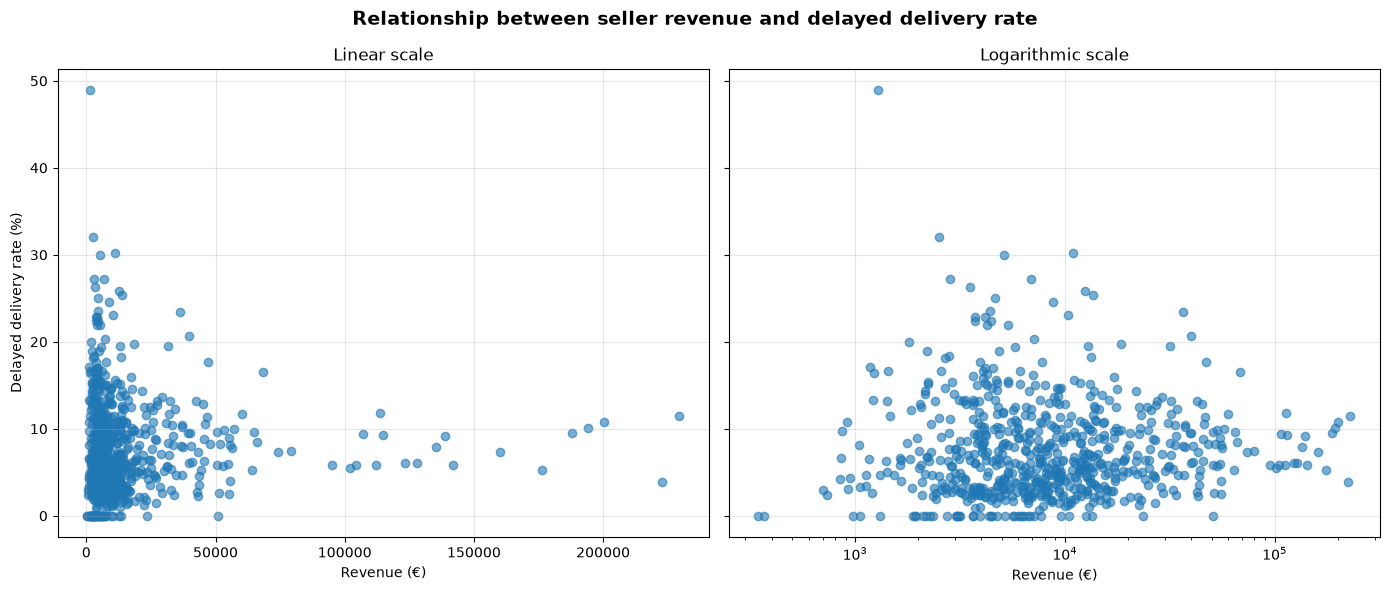

In [159]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Linear scale
axes[0].scatter(
    seller_performance_pd["income"],
    seller_performance_pd["delay_rate"],
    alpha=0.6
)

axes[0].set_title("Linear scale")
axes[0].set_xlabel("Revenue (€)")
axes[0].set_ylabel("Delayed delivery rate (%)")
axes[0].grid(alpha=0.3)

# Logarithmic scale
axes[1].scatter(
    seller_performance_pd["income"],
    seller_performance_pd["delay_rate"],
    alpha=0.6
)

axes[1].set_xscale("log")
axes[1].set_title("Logarithmic scale")
axes[1].set_xlabel("Revenue (€)")
axes[1].grid(alpha=0.3)

fig.suptitle(
    "Relationship between seller revenue and delayed delivery rate",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

La distribución de ingresos presenta una fuerte asimetría hacia la derecha. Por este motivo, se representa la relación entre ingresos y porcentaje de pedidos retrasados utilizando tanto una escala lineal como una logarítmica en el eje X, facilitando la interpretación de vendedores con distintos volúmenes de facturación.

- No se aprecia una correlación clara entre los ingresos del vendedor y su tasa de retrasos.
- Los vendedores con mayores ingresos (a la derecha) mantienen tasas de retraso similares a las del resto, generalmente entre el 3% y el 12%.
- La mayor dispersión se concentra en vendedores con menores ingresos, donde aparecen tanto tasas muy bajas como algunos valores elevados. Esto puede deberse a una mayor variabilidad en vendedores con menor volumen de actividad, incluso tras el filtrado de 30 pedidos.
- No se observa una tendencia ascendente o descendente que sugiera que vender más implique sistemáticamente más o menos retrasos.

In [166]:
# ¿Qué estados o ciudades concentran más vendedores?
state_sellers = (
    order_items
    .join(
        sellers.select("seller_id", "seller_state"),
        on="seller_id"
    )
    .groupBy("seller_state")
    .agg(
        F.countDistinct("seller_id").alias("num_sellers"),
        F.countDistinct("order_id").alias("num_orders"),
        F.round(F.sum("price"), 2).alias("product_income"),
        F.round(F.sum("freight_value"), 2).alias("freight_income")
    )
)

state_sellers.orderBy(F.desc("num_sellers")).show(10)

+------------+-----------+----------+--------------+--------------+
|seller_state|num_sellers|num_orders|product_income|freight_income|
+------------+-----------+----------+--------------+--------------+
|          SP|       1849|     70188|    8753396.21|    1482487.67|
|          PR|        349|      7673|    1261887.21|     197013.52|
|          MG|        244|      7930|    1011564.74|     212595.06|
|          SC|        190|      3667|     632426.07|     106547.06|
|          RJ|        171|      4353|     843984.22|       93829.9|
|          RS|        129|      1989|     378559.54|      57243.09|
|          GO|         40|       463|      66399.21|       12565.5|
|          DF|         30|       824|      97749.48|      18494.06|
|          ES|         23|       318|      47689.61|      12171.13|
|          BA|         19|       569|     285561.56|      19700.68|
+------------+-----------+----------+--------------+--------------+
only showing top 10 rows


In [173]:
# ¿Influye el peso del producto en el tiempo de entrega?
from pyspark.ml.feature import Bucketizer

# Calculamos nueva columna
orders = orders.withColumn(
    "delivery_days",
    F.datediff(
        F.col("order_delivered_customer_date"),
        F.col("order_purchase_timestamp")
    )
)


delivery_by_weight = order_items\
    .join( products.select('product_id','product_weight_g'), 
          on='product_id')\
    .join( orders.select('order_id','delivery_state', 'delivery_days','delay_days'), 
          on= 'order_id')\
    .filter(
        F.col('product_weight_g').isNotNull()
    )


# binarizer by weight
splits = [0, 500, 1000, 2000, 5000, float("inf")]

bucketizer = Bucketizer(
    splits=splits,
    inputCol="product_weight_g",
    outputCol="weight_bucket"
)

delivery_by_weight = bucketizer.transform(delivery_by_weight)

# mappings values for legibility
delivery_by_weight = (
    delivery_by_weight
    .withColumn(
        "weight_range",
        F.when(F.col("weight_bucket") == 0, "≤ 0.5 kg")
         .when(F.col("weight_bucket") == 1, "0.5 - 1 kg")
         .when(F.col("weight_bucket") == 2, "1 - 2 kg")
         .when(F.col("weight_bucket") == 3, "2 - 5 kg")
         .otherwise("> 5 kg")
    )
    .drop("weight_bucket")
)



delivery_by_weight = delivery_by_weight.groupBy('weight_range')\
    .agg(
        F.count('*').alias('num_orders'), 
        F.round(F.avg("delivery_days"), 2).alias("avg_delivery_days"),
        F.round(F.avg("delay_days"), 2).alias("avg_delay_days"),
    )

delivery_by_weight.show()

+------------+----------+-----------------+--------------+
|weight_range|num_orders|avg_delivery_days|avg_delay_days|
+------------+----------+-----------------+--------------+
|  0.5 - 1 kg|     21816|            12.18|          8.75|
|      > 5 kg|     14009|             14.2|          9.18|
|    1 - 2 kg|     20288|            12.77|          9.14|
|    2 - 5 kg|     11729|            12.84|          9.39|
|    ≤ 0.5 kg|     44790|            11.69|           8.2|
+------------+----------+-----------------+--------------+



Conclusión: El peso del producto parece tener una influencia limitada sobre el tiempo de entrega. Aunque los artículos de mayor peso (>5 kg) presentan un tiempo medio de entrega superior, no se observa una relación lineal o una correlación fuerte entre ambas variables.

#### Ventas / KPIs generales
- ¿Cuál es el volumen total de ventas?
- ¿Cómo evolucionan las ventas mes a mes?
- ¿Cuál es el ticket medio por pedido?


In [175]:
order_items.columns

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [183]:
# ¿Cuál es el volumen total de ventas?
sales_summary = order_items\
    .agg(
        F.countDistinct("order_id").alias("num_orders"), 
        F.count("*").alias("products_sold"),
        F.round(F.sum("price"),2).alias('total_income'),
    )

sales_summary.show(5,truncate=False)

+----------+-------------+------------+
|num_orders|products_sold|total_income|
+----------+-------------+------------+
|98666     |112650       |1.35916437E7|
+----------+-------------+------------+



In [184]:
orders.columns

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_state',
 'delay_days',
 'delivery_days']

In [188]:
# ¿Cómo evolucionan las ventas mes a mes?

monthly_sales = order_items\
    .join(orders.select('order_id','order_purchase_timestamp'), on='order_id')\
    .withColumn('year_month', F.date_format('order_purchase_timestamp', "yyyy-MM") )\
    .groupBy('year_month')\
    .agg(
        F.countDistinct('order_id').alias('num_orders'),
        F.count("*").alias('num_products_sold'),
        F.round(F.sum('price'),2).alias('total_sales')
    )\
    .orderBy('year_month',ascending=True)
    
monthly_sales.show(10)

+----------+----------+-----------------+-----------+
|year_month|num_orders|num_products_sold|total_sales|
+----------+----------+-----------------+-----------+
|   2016-09|         3|                6|     267.36|
|   2016-10|       308|              363|   49507.66|
|   2016-12|         1|                1|       10.9|
|   2017-01|       789|              955|  120312.87|
|   2017-02|      1733|             1951|  247303.02|
|   2017-03|      2641|             3000|   374344.3|
|   2017-04|      2391|             2684|  359927.23|
|   2017-05|      3660|             4136|  506071.14|
|   2017-06|      3217|             3583|   433038.6|
|   2017-07|      3969|             4519|  498031.48|
+----------+----------+-----------------+-----------+
only showing top 10 rows


In [190]:

from pyspark.sql.window import Window

window = Window.orderBy("year_month")

cumulative_monthly_sales = (
    monthly_sales
    .withColumn(
        "previous_month_sales",
        F.lag("total_sales").over(window)
    )
    .withColumn(
        "sales_growth_pct",
        F.round(
            (
                (F.col("total_sales") - F.col("previous_month_sales"))
                / F.col("previous_month_sales")
            ) * 100,
            2
        )
    )
)
cumulative_monthly_sales.show(5)

+----------+----------+-----------------+-----------+--------------------+----------------+
|year_month|num_orders|num_products_sold|total_sales|previous_month_sales|sales_growth_pct|
+----------+----------+-----------------+-----------+--------------------+----------------+
|   2016-09|         3|                6|     267.36|                NULL|            NULL|
|   2016-10|       308|              363|   49507.66|              267.36|        18417.23|
|   2016-12|         1|                1|       10.9|            49507.66|          -99.98|
|   2017-01|       789|              955|  120312.87|                10.9|       1103687.8|
|   2017-02|      1733|             1951|  247303.02|           120312.87|          105.55|
+----------+----------+-----------------+-----------+--------------------+----------------+
only showing top 5 rows


Los primeros meses del dataset contienen un volumen muy reducido de pedidos, por lo que las variaciones porcentuales iniciales no son representativas y no deben interpretarse como tendencias del nego

In [192]:
cumulative_monthly_sales_pd = cumulative_monthly_sales.toPandas()

/Users/gloriadelriomarquez/Documents/Career/spark-lab/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/Users/gloriadelriomarquez/Documents/Career/spark-lab/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


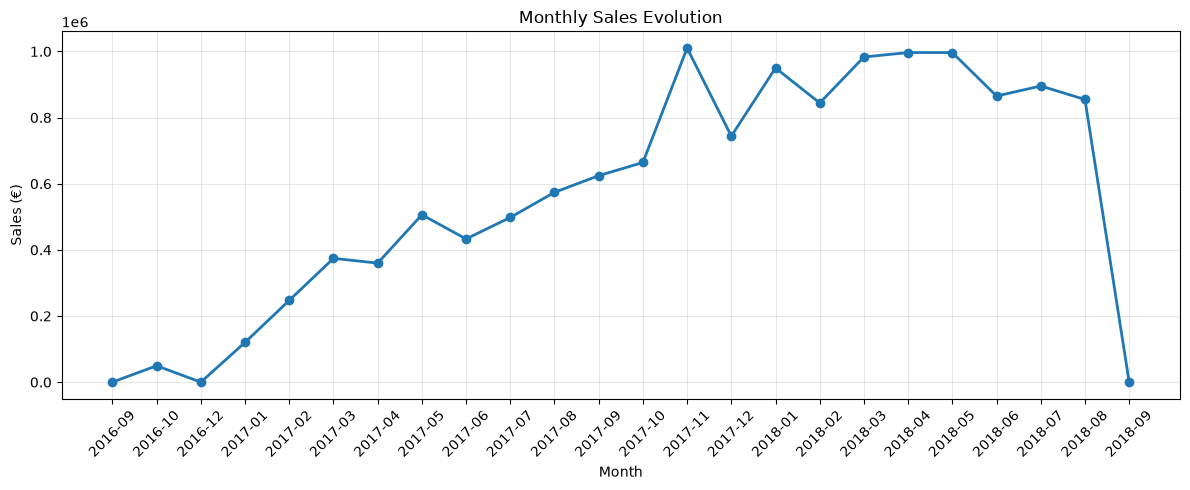

In [194]:
plt.figure(figsize=(12,5))
plt.plot(cumulative_monthly_sales_pd["year_month"], cumulative_monthly_sales_pd["total_sales"], marker="o", linewidth=2)

plt.title("Monthly Sales Evolution")
plt.xlabel("Month")
plt.ylabel("Sales (€)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()